# Polyply Tutorial PEGylation

Enhancement of proteins by conjugation polymers is an active area of research. However, the interactions between polymers and proteins are far from fully understood. To gain better insight into these interactions or even make predictions, molecular dynamics (MD) simulations can be applied to study specific protein-polymer systems in molecular detail. Here, we present instructions for simulating protein-polymer conjugates using the latest iteration of the Martini coarse-grained (CG) force field. In particular, site-specific PEGylations and PASylations are discussed as examples illustrating the more general approach. 

## Table of Contents

- 1.0 Generating Protein Simulation Parameters for Lysozyme
- 2.0 Generating Parameters for PEGylation of CYS114 in Lysozyme
- 3.0 Generating Starting Coordinates for PEGylated Lysozyme
- 3.1 Inital Coordinate Generation
- 3.2 Equilibriation 
- 4.0 PASylation

## Installation Requirements
- protein repair and analysis server
- vermouth-martinize
- cgsmiles
- polyply
- gromacs-wrapper 
- vermouth

# 0.0 Auxilliary Functions for Plotting 

In [1]:
from cgsmiles.drawing import draw_molecule
import matplotlib.pyplot as plt
from polyply.src.simple_seq_parsers import ONE_LETTER_AA
import os
import nglview as nv

AA_LETTER_ONE = {j: i for i, j in ONE_LETTER_AA.items()}

def resname_to_one_letter(protein):
    mapping = {"ALA": "A"}
    labels = {}
    for node in protein:
        resname = protein.nodes[node]['resname']
        resid = protein.nodes[node]['resid']
        labels[node] = AA_LETTER_ONE.get(resname, resname)+str(resid)
    return labels

cwd = os.getcwd()

# 1.0 Generating Protein Simulation Paramters



First we need to fix any structural issues with the protein coordinates and add the hydrogen atoms. The protein repair and analysis server will take care of it and produce the `3LZT_out.cif`, required to martinize the protein.

In [2]:
import time
from Pras_Server.RunType import InitRunType
from Pras_Server.PDBID import  _82_pdbs, _494_pdbs

startTime = time.time()

fixing = InitRunType( rotamer="", mutation="", pdb_faspr="", keep_ligand="", chain_no="", 
              addh=False, ss=False, raman=False, ofname=False, pdbid=["3LZT.cif"], his_p=False)

fixing.ProcessWithoutDefaultUsingPDBID()

fixed 3LZT.cif


Then we can run martinize2 to produce a coarse-grained model for lysozyme using a Go model structural bias.

In [3]:
!martinize2 -f '3LZT_out.cif' -ff 'martini3001' -o '3lzt.top' -x '3lzt.pdb' -dssp -go

    INFO - general - _cell information missing from .cif file. Will write default dimensions
    INFO - step - Guessing the bonds.
    INFO - general - 1 molecules after guessing bonds
    INFO - step - Repairing the graph.
    INFO - general - Applying modification N-ter to residue A-LYS1
    INFO - general - Applying modification + to residue A-LYS1
    INFO - general - Applying modification C-ter to residue A-LEU129
    INFO - general - Applying modification + to residue A-LEU129
    INFO - step - Dealing with modifications.
    INFO - general - Identified the modifications ['N-ter'] on residues ['LYS1', 'LYS1', 'LYS1', 'LYS1']
    INFO - general - Identified the modifications ['C-ter'] on residues ['LEU129', 'LEU129', 'LEU129']
    INFO - step - Read input.
    INFO - step - Generating Go model contact map.
    INFO - general - Calculating Go contacts for 129 residues (1001 atoms)
    INFO - general - Contact map complete: 1198 Go contacts identified
    INFO - step - Creating the 

Before we proceed it is recommended to center the protein in a box.

In [4]:
! gmx editconf -f 3lzt.pdb -o 3lzt_center.pdb -box 10. 10. 10. -center 5. 5. 5

                :-) GROMACS - gmx editconf, 2024.2-Homebrew (-:

Executable:   /opt/homebrew/bin/../Cellar/gromacs/2024.2/bin/gmx
Data prefix:  /opt/homebrew/bin/../Cellar/gromacs/2024.2
Working dir:  /Users/fabian/ProgramDev/tutorials/protein_bioconjugates
Command line:
  gmx editconf -f 3lzt.pdb -o 3lzt_center.pdb -box 10. 10. 10. -center 5. 5. 5

Note that major changes are planned in future for editconf, to improve usability and utility.
Read 433 atoms
No velocities found
    system size :  2.727  3.565  4.291 (nm)
    center      : -0.118  1.440  2.418 (nm)
    box vectors :  0.000  0.000  0.000 (nm)
    box angles  :   0.00   0.00   0.00 (degrees)
    box volume  :   0.00               (nm^3)
    shift       :  5.118  3.560  2.582 (nm)
new center      :  5.000  5.000  5.000 (nm)
new box vectors : 10.000 10.000 10.000 (nm)
new box angles  :  90.00  90.00  90.00 (degrees)
new box volume  :1000.00               (nm^3)

GROMACS reminds you: "All sorts of things can happen when you're

# 2.0 Generating PEGylated Protein Parameters

Before we start we need to import the `gen_params` function, which will generate the simulation input paramters. Additionally, we need the `MetaMolecule` object that stores the residue graph of our PEGylated protein. The `force_field` object is a storage class, that collects all molecule definitions. 

In [5]:
from pathlib import Path
from vermouth.forcefield import ForceField
from polyply import gen_params
from polyply.src.meta_molecule import MetaMolecule
import networkx as nx
ff = ForceField("PEGylation")

First we load the itp file generated by vermouth to extract the residue graph / sequence of the protein

In [6]:
# step 1: load protein residue graph from ITP file
itp_file="molecule.itp" 
protein = MetaMolecule.from_itp(force_field=ff, 
                                itp_file="molecule.itp", 
                                mol_name="molecule")
# needed for plotting
nx.set_edge_attributes(protein, 1 , 'order')

Using the cgsmiles draw_molecule utility we can draw the sequence graph of the protein. The labels function will annotate each node with the one letter amino acid code and the residue index. 

In [7]:
from cgsmiles.drawing import draw_molecule
import matplotlib.pyplot as plt
labels = resname_to_one_letter(protein)

Furthermore, we highlight the all LYS residues in green and the Cysteine residues in yellow.

In [8]:
colors={idx: 'lightgray' for idx in range(0, 130)}
for node in protein.nodes:
    if protein.nodes[node]['resname'] == 'CYS':
        colors[node] = 'gold'
    if protein.nodes[node]['resname'] == 'PHE':
        colors[node] = 'tab:green'

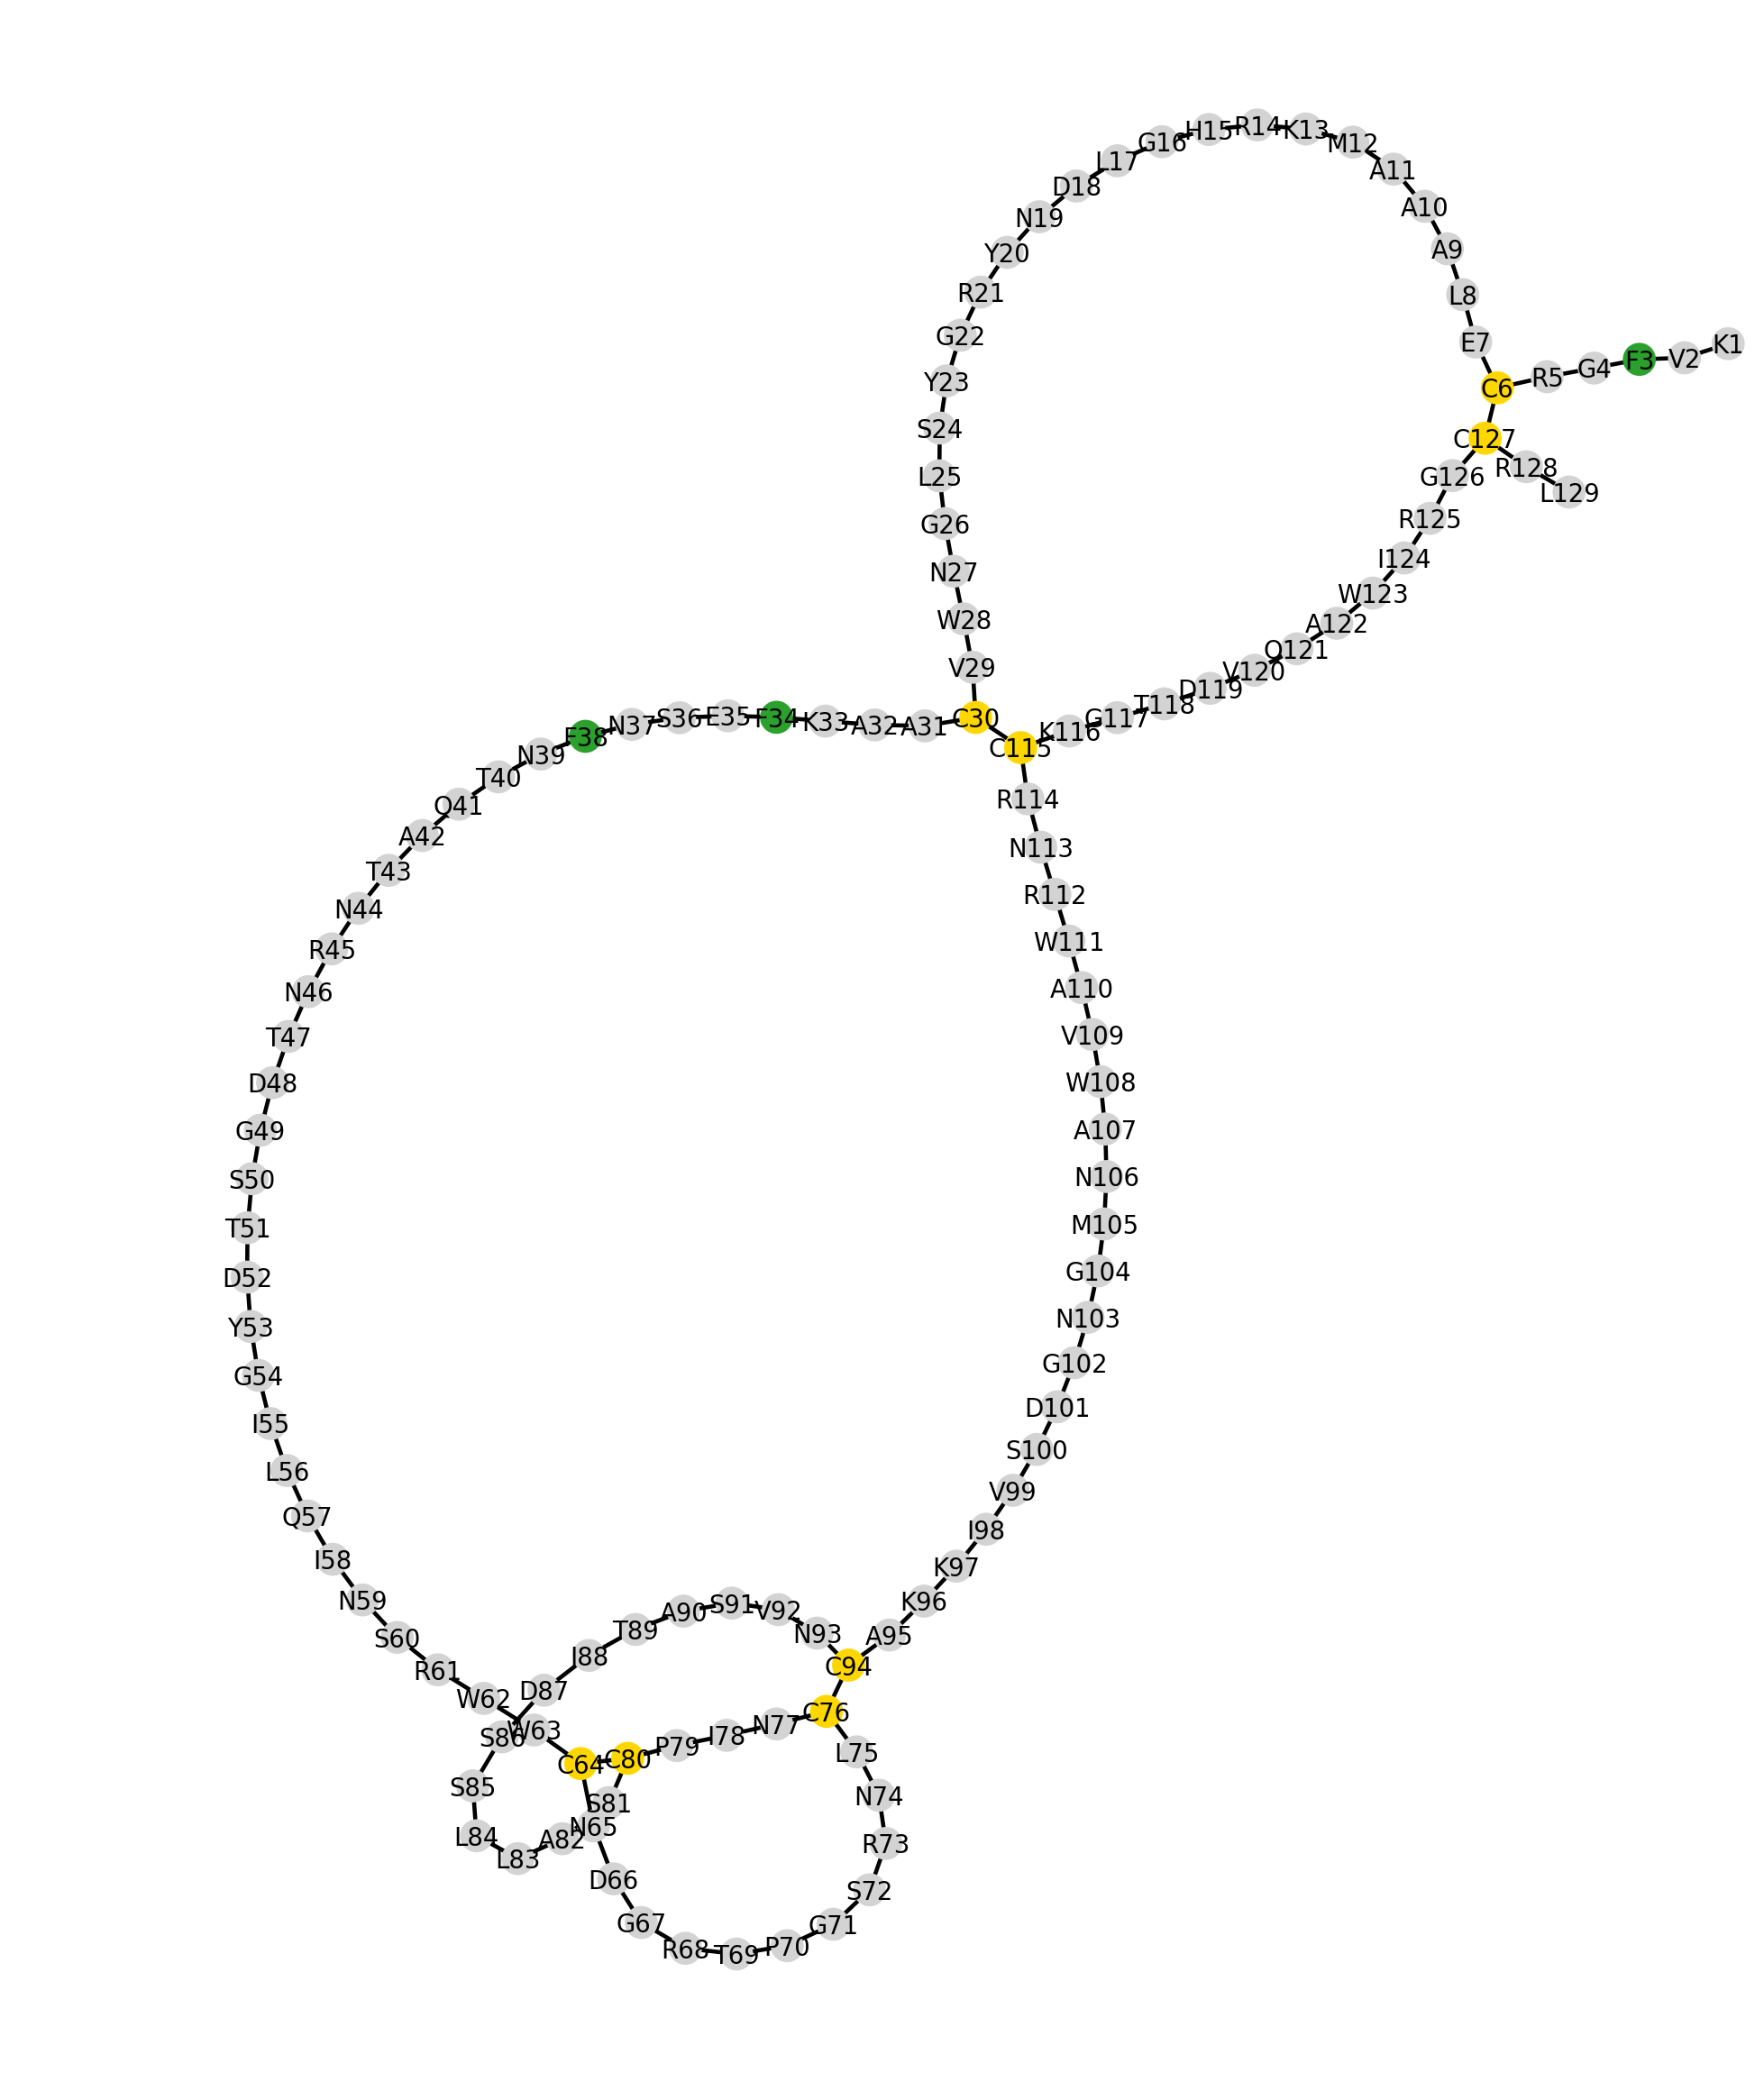

In [9]:
fig, axs = plt.subplots(1,1,figsize=(25,30))
_ = draw_molecule(protein, 
                  cg_mapping=False, 
                  layout_method='vespr', 
                  colors=colors, 
                  scale=1.1, 
                  labels=labels,
                  fontsize=18)

The graph shows us several interesting things. First, we can see that the residue graph is not just linear due to the cysteine brdiges being formed. We can also see that all Cysteines are participating in those rendering them typically inaccesible to PEGylation. Therefore, let's take PHE34 (F34) as target. 

Next, we need to define the residue graph of the polymer that we want to add to the protein. For PEGylation that is simply PEG, but we also need to define the chemical linker that syntehtically connnects PEG to the protein. Polyply offers 5 different linker types arising from typical chemistries of synthetically linking PEG to a protein. Phenyalaline like residues can be targeted by replacing them with the non-nantural amino acid 4-Azido-L-phenylalanine and performing click chemistry. Within polyply the resulting fragment is called APA and can be directly linked to any Phenylalanine.

To define the residue graph of the polymer we use a CGsmiles string. CGsmiles can describe abitary resolutions of molecules and their connectivity. 

In [10]:
# step 2: load PEG residue graph from CGsmiles string
cgsmiles_str="{[#APA][#EO]|10[#OHter]}"
polymer = MetaMolecule.from_cgsmiles_str(force_field=ff,
                                         cgsmiles_str=cgsmiles_str, 
                                         mol_name="PEO")
# needed for plotting only
nx.set_edge_attributes(protein, 1 , 'order')

Using the draw molecules function, we can again draw the residue graph and see that this one is indeed linear. 

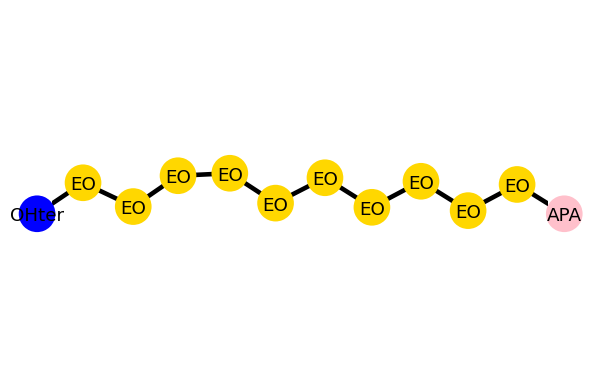

In [11]:
colors = {}
for node in polymer.nodes:
    if  polymer.nodes[node]['resname'] == 'EO':
        colors[node] = 'gold'
    elif  polymer.nodes[node]['resname'] == 'OHter':
        colors[node] = 'blue'
    elif  polymer.nodes[node]['resname'] == 'APA':
        colors[node] = 'pink'
labels = nx.get_node_attributes(polymer, 'resname')
_ = draw_molecule(polymer, 
              cg_mapping=False,
              layout_method='vespr', 
              colors=colors, 
              scale=1.1, 
              labels=labels,
              fontsize=12,
              align_with='x')

Now, we can add the polymer to the protein by merging the two `MetaMolecule` objects and specifying which residue connects the protein to the polymer. Note that the indinces start at zero. 

In [12]:
# step 3: add PEG to protein and connect K33 to first PEG unit
protein.merge_meta_mol(polymer, connects=[(33, 0)])

Again the residue graph can be drawn. 

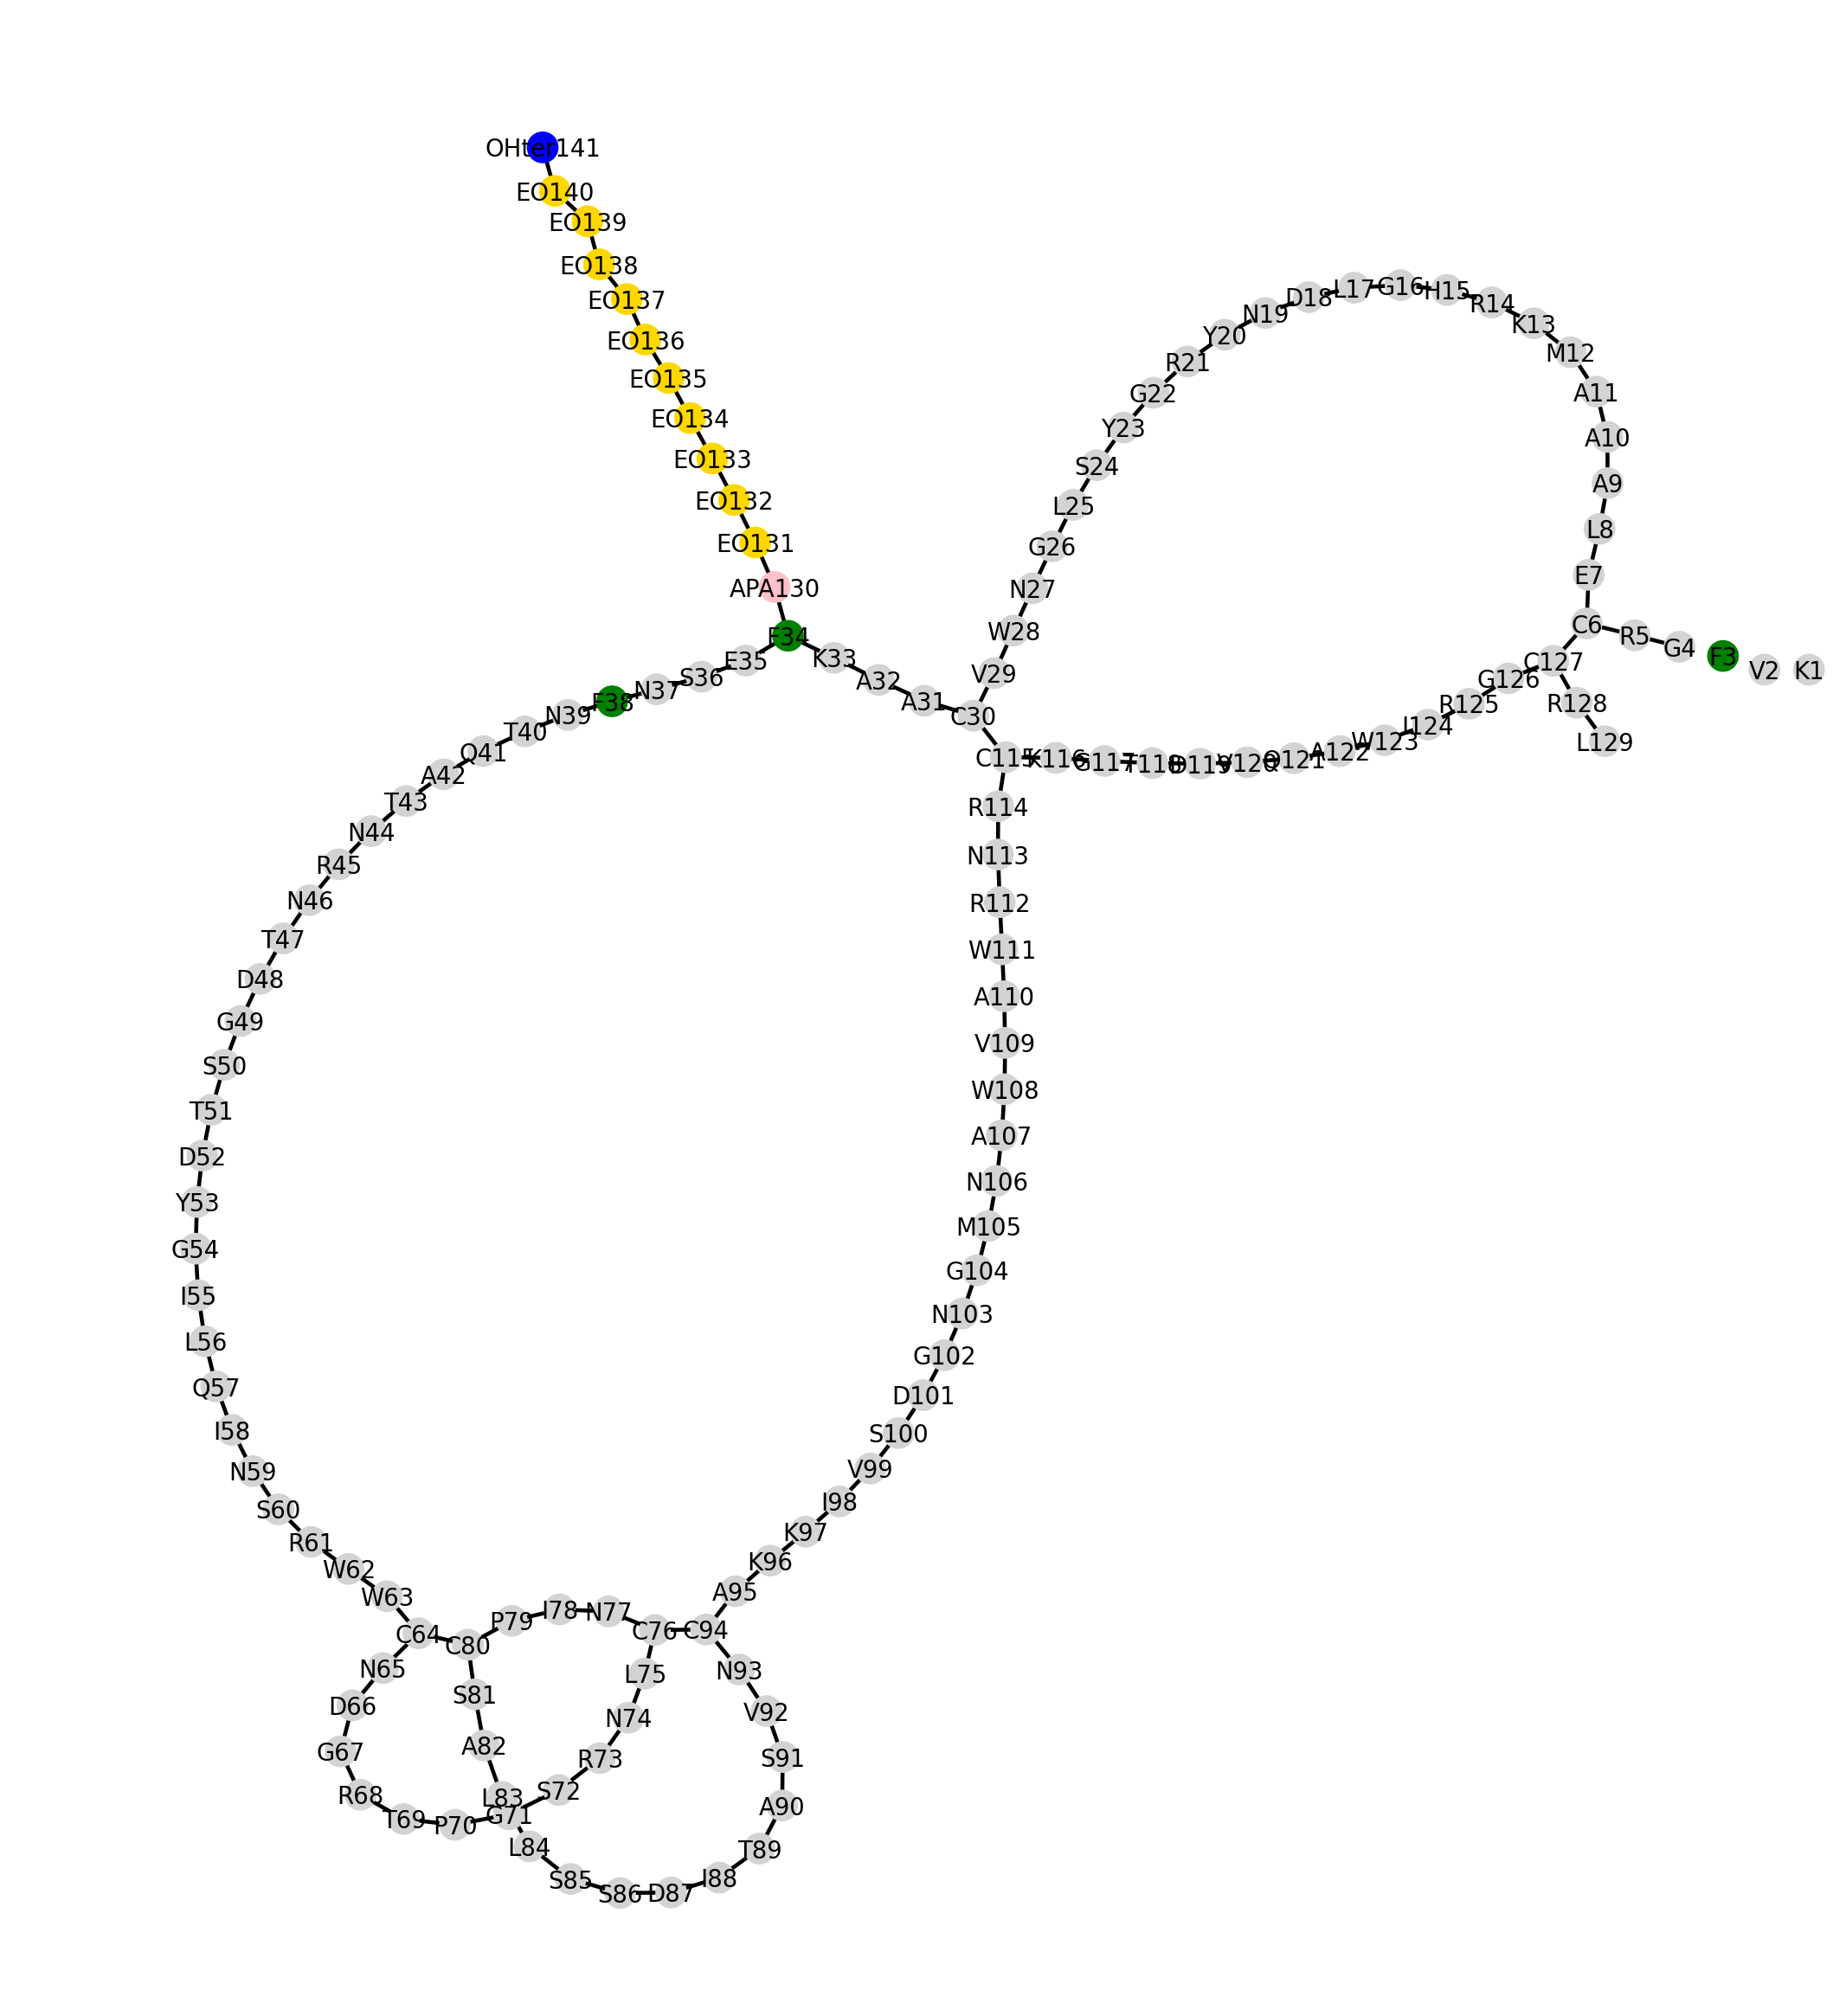

In [13]:
colors = {}
labels = resname_to_one_letter(protein)
for node in protein.nodes:
    if  protein.nodes[node]['resname'] == 'EO':
        colors[node] = 'gold'
    elif  protein.nodes[node]['resname'] == 'OHter':
        colors[node] = 'blue'
    elif  protein.nodes[node]['resname'] == 'APA':
        colors[node] = 'pink'
    elif protein.nodes[node]['resname'] == 'PHE':
        colors[node] = 'green'
    else: 
        colors[node] = 'lightgray'


fig, axs = plt.subplots(1,1,figsize=(25,30))
_ = draw_molecule(protein, 
                  cg_mapping=False, 
                  layout_method='vespr', 
                  colors=colors, 
                  scale=1.1, 
                  labels=labels,
                  fontsize=18)

Finally, the parameters are generated using the `gen_params` utility. As input we need to define the `molecule.itp` file from the `martinize2` step and the martini3 library storing the PEGylation paramters. This call will write the `lysoPEG.itp` file that stores all simulation input paramters. 

In [14]:
gen_params(inpath=[Path("molecule.itp")],
           lib=["martini3"],
           meta_molecule=protein,
           name="lysoPEG",
           outpath=Path("lysoPEG.itp"))

100%|█████████████████████████████████████████████████████████████████████████████████████| 144/144 [00:00<00:00, 572.83it/s]


# 3 Structure generation and simulation of PEGylated Proteins

Before we can start the simulation, one needs the input coordinates. For the protein part they are directly transformed from the PDB structure file using Martinize2. To generate the solvate the system and generate the polymer coordinates, we use the `gen_coords` utility. It's input is the GROMACS topology file and the coordinates of the protein. `gen_coords` will automatically create all the missing coordinates. 

In [15]:
toplines="""#include "martini_v3.0.0.itp"
#include "go_atomtypes.itp"
#include "go_nbparams.itp"
#include "martini_v3.0.0_solvents_v1.itp"
#include "martini_v3.0.0_ions_v1.itp"
#include "lysoPEG.itp"

[ system ]
Title of the system

[ molecules ]
lysoPEG 1
W 10000
NA 100
CL 108"""
with open("lysoPEG.top", "w") as _file:
    _file.write(toplines)

In the `gen_coords` the **martini density** of the system needs to be specified. Note that for aqueous systems it is close to 1000. For polymer systems it might singifcantly deviate.

In [16]:
from polyply import gen_coords
import gromacs as gmx
import os

# step 1: generate the missing PEGylation coordinates and solvate
gen_coords(toppath=Path("lysoPEG.top"), 
           density=1000, 
           outpath=Path("lyso_PEG_start.gro"), 
           coordpath=Path("3lzt_center.pdb"),
           name="lysoPEG")

A density is provided via the command line, but the starting coordinates define a box.Will try to pack all molecules in the box provided with starting coordinates.
100%|████████████████████████████████████████████████████████████████████████████████| 10209/10209 [00:01<00:00, 6703.16it/s]


After coordinate generation they need to be relaxed and then we can run a simulaiton. The functions below perform an energy minimization followed by nvt and npt equilibriation. 

In [17]:
#sim_dir="simulation"
#if os.path.isdir(sim_dir):
#    os.rmdir(sim_dir)
#os.mkdir(sim_dir)
#os.chdir(sim_dir)
# step 2: equilibriate the system and start production simulation
#prev_stage="../start"
#for stage in ["mini", "nvt", "prod"]:
#    gmx.grompp(f=f"../cg_mdps/{stage}.mdp",
#               c=f"{prev_stage}.gro", 
#               p="../lysoPEG.top",
#               o=f"{stage}.tpr")
#    gmx.mdrun(deffnm=stage, 
#              v=False, 
#              s=f"{stage}.tpr")
#    prev_stage = stage

# PASylation

PASylation is an alternative to PEG conjugation, where sequences of Proline, Alanine, and Cysteine that are disordered and lack secondary structure motifs are attached to the protein at the termini via recombinant methods. To add PASylations to a protein and simulate it in the Martini 3 framework, the steps are nearly identical to those for N-terminal PEGylation. However, we need to generate a random PAS sequence that does not include repeats. This sequence can be obtained using the CGsmiles MoleculeSampler utility.

In [18]:
import os
from cgsmiles import MoleculeSampler
from pathlib import Path
from vermouth.forcefield import ForceField
from polyply import gen_params
from polyply.src.meta_molecule import MetaMolecule
from cgsmiles.write_cgsmiles import write_cgsmiles_graph
import pysmiles
import vermouth 
import networkx as nx
os.chdir(cwd)

As input for the `MoleculeSampler` one needs to define the monomer structures of the three amino-acids of intrest (i.e. ALA, SER, PRO). This can be done either at all-atom or any other level of resolution (e.g. Martini). In the definitions below, the bonding operators `>` and `<` form the peptide bond and mean only different connectors can connect. 

In [19]:
# step 1: define amino acids at Martini level and add two
# bonding descriptors 
amino_acids = "{#ALA=CC(C(=O)O[$AO])N[$AN],\
#SER=C(C(C(=O)O[$SO])N[$SN])O,\
#PRO=C1CC(N[$PN]C1)C(=O)O[$PO]}"

In addition to the structures, reactivities between the different amino acids should be defined. It is important that PASylation avoids large stretches of homopolymer blocks. Therefore the reactivity between an amino acids and itself is set to zero. The dict below enumerates the reactivity between all the different bonding connects. Note that we could also set the probability of reacting with itself to a value smaller than the other depending on what outcome of a reaction we want to model.

In [20]:
# step 2: define the probability a bonding connector can 
# connect to another one
reactivities = {"$AO":{"$AO": 0.0, "$AN":0.0, "$PO": 0.5, "$PN": 0.0, "$SO":0.5 , "$SN": 0.0},
                "$AN":{"$AO": 0.0, "$AN":0.0, "$PO": 0.0, "$PN": 0.5, "$SO":0.0 , "$SN": 0.5},
                "$SO":{"$AO": 0.0, "$AN":0.5, "$PO": 0.5, "$PN": 0.0, "$SO":0.0 , "$SN": 0.0},
                "$SN":{"$AO": 0.0, "$AN":0.5, "$PO": 0.0, "$PN": 0.5, "$SO":0.0 , "$SN": 0.0},
                "$PO":{"$AO": 0.0, "$AN":0.5, "$PO": 0.0, "$PN": 0.0, "$SO":0.5 , "$SN": 0.0},
                "$PN":{"$AO": 0.5, "$AN":0.0, "$PO": 0.0, "$PN": 0.0, "$SO":0.0 , "$SN": 0.5},
               }
masses = {"ALA": 89.094,"SER": 105.093, "PRO": 115.132}

With this in mind, we can now sample a random polymer/protein given a target molecular weight (`target_weigth`). The result is a graph of a random homopolymer of ALA, SER, PRO at full atomic resolution. We can start by making a very short peptide targeting only 500 g/mol. 

In [21]:
# step 3: generate a random sequence with a target molecular
# weight; note that the weight of the AAs needs to be defined 
sampler = MoleculeSampler.from_fragment_string(amino_acids,
                          polymer_reactivities={"ALA":1, "PRO":1, "SER":1},
                          fragment_reactivities=reactivities,
                          fragment_masses=masses, all_atom=True)
pas_graph = sampler.sample(target_weight=500)

/Users/fabian/ProgramDev/dev_env/lib/python3.9/site-packages/cgsmiles/sample.py:20: RuntimeWarning: invalid value encountered in divide
  probs = probs / sum(probs)


Let's draw the molecule. We remove the hydrogen atoms, for efficency. The coloring of the different residues is by amino acid name, so we can directly see if our protcol worked. 

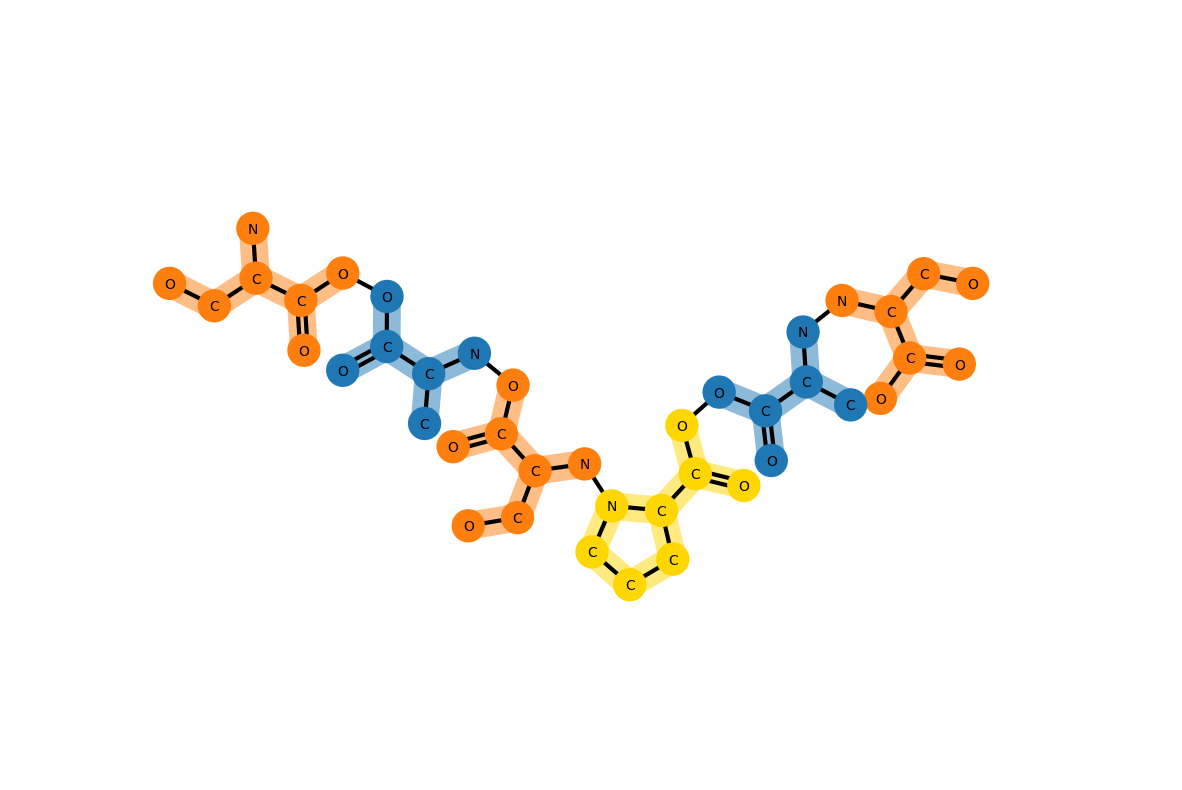

In [22]:
fig, axs = plt.subplots(1,1,figsize=(15,10))
pysmiles.remove_explicit_hydrogens(pas_graph)
colors = {}
color_mapping = {"ALA": "tab:blue", "PRO": "gold", "SER": "tab:orange"}
for node in pas_graph.nodes:
    colors[pas_graph.nodes[node]['fragid'][0]] = color_mapping[pas_graph.nodes[node]['fragname']]
_ = draw_molecule(pas_graph, scale=1.0, align_with='x', colors=colors)

As has already been introduced, polyply works on the level of a residue graph. So from the full molecule graph, we have to extract the residue graph. To do so we first convert the fragment index, which is a list for CGsmiles graphs, to the residue index and fragname to resname. Subsequently, `_block_graph_to_res_graph` from the `MetaMolecule` preparese the graph from which the MetaMolecule can be prepared.

In [23]:
# step 4: create the MetaMolecule 
for node in pas_graph.nodes:
    pas_graph.nodes[node]['resid'] =  pas_graph.nodes[node]['fragid'][0]
    pas_graph.nodes[node]['resname'] =  pas_graph.nodes[node]['fragname']
    
tmp = MetaMolecule._block_graph_to_res_graph(pas_graph)
pas_seq = MetaMolecule(tmp)
print(f"This peptide has {len(pas_seq)} residues.")

This peptide has 6 residues.


Finally, obtaining the itp file works exactly the same way as for the PEGylation: 1) merging the PASylation onto the `MetaMolecule`, 2) giving it to the `gen_params`. 

In [24]:
ff = ForceField("PEGylation")
# step 5: load protein residue graph from ITP file
protein = MetaMolecule.from_itp(force_field=ff, 
                                itp_file="molecule.itp", 
                                mol_name="molecule")

# step 7: connect the last PAS residue to the first on lysozyme
protein.merge_meta_mol(pas_seq, connects=[(0, 0)])
# needed for plotting only
nx.set_edge_attributes(protein, 1 , 'order')

To check that this works, we can draw the graph again:

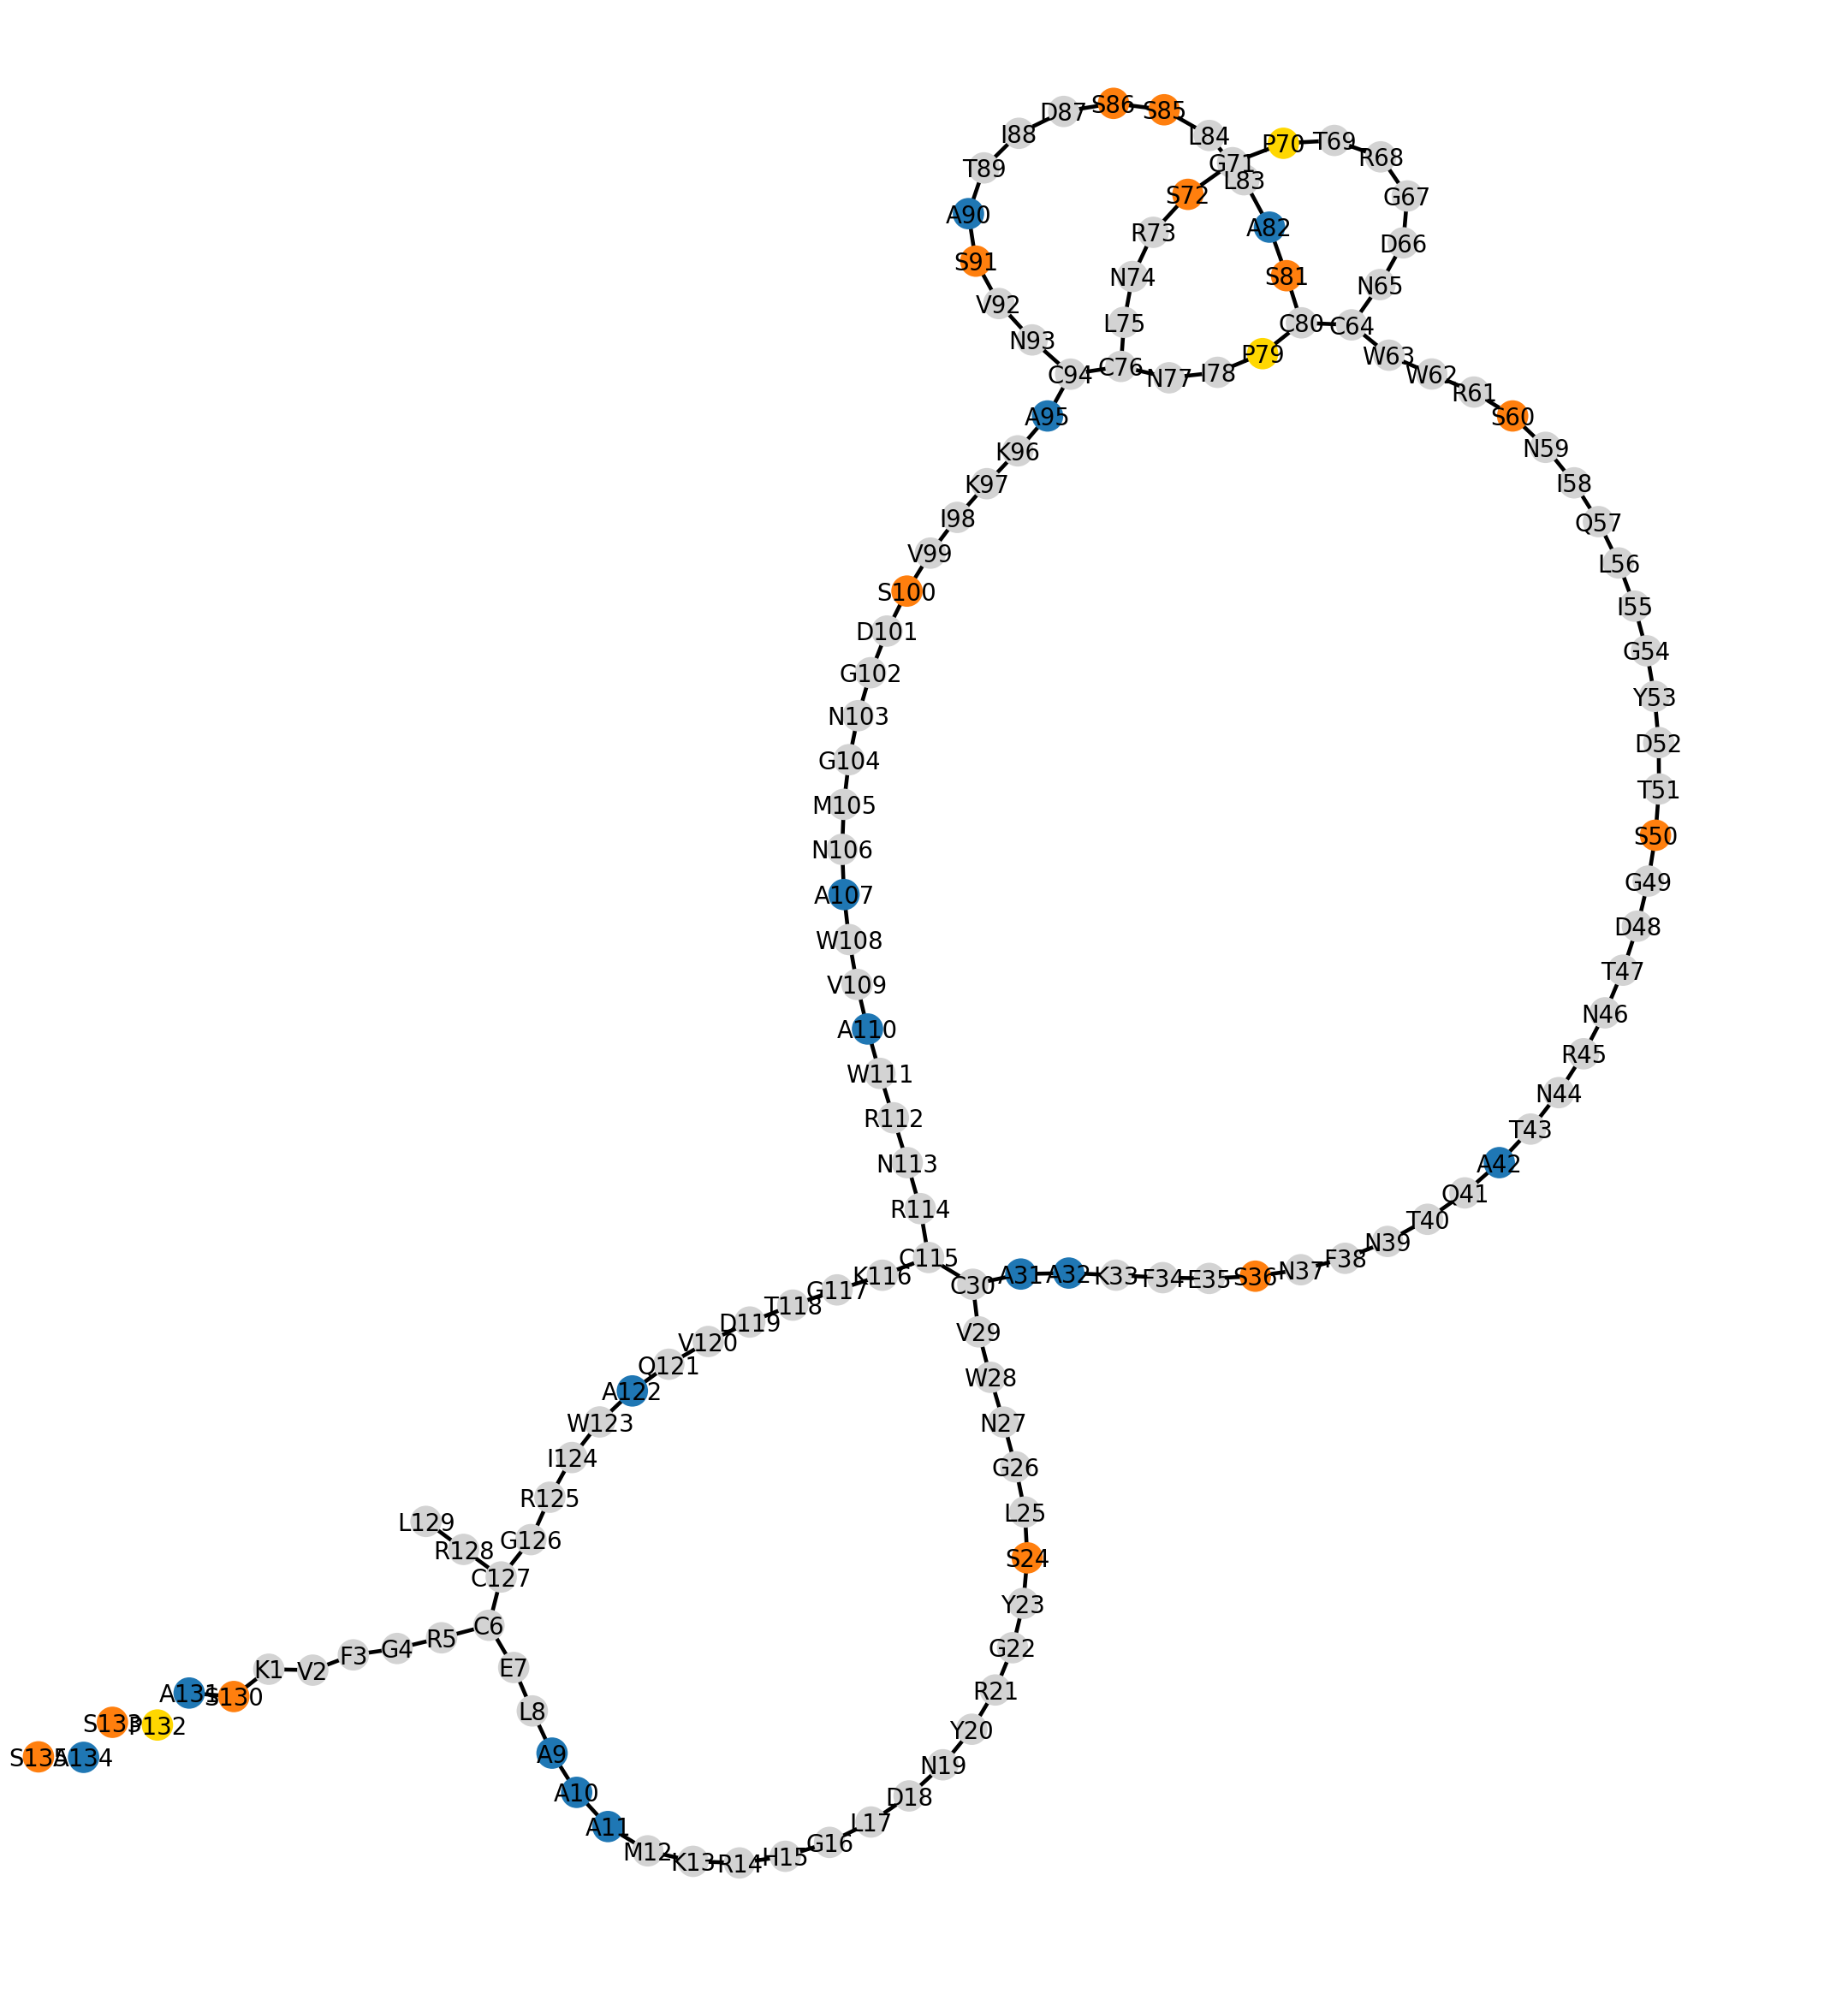

In [25]:
colors = {}
labels = resname_to_one_letter(protein)
for node in protein.nodes:
    colors[node] =  color_mapping.get(protein.nodes[node]['resname'], 'lightgray')

fig, axs = plt.subplots(1,1,figsize=(25,30))
_ = draw_molecule(protein, 
                  cg_mapping=False, 
                  layout_method='vespr', 
                  colors=colors, 
                  scale=1.1, 
                  labels=labels,
                  fontsize=18)

In [26]:
gen_params(inpath=[Path("molecule.itp")],
           outpath=Path("lysoPAS.itp"),
           lib=["martini3"],
           name="lysoPAS",
           meta_molecule=protein)

100%|█████████████████████████████████████████████████████████████████████████████████████| 134/134 [00:00<00:00, 673.72it/s]


# PASylation coordinates

The coordinates can be generated in exactly the same fashion as before: 1) write a valid topology file; 2) run `gen_coords` providing the system target density. 

In [27]:
toplines="""#include "martini_v3.0.0.itp"
#include "go_atomtypes.itp"
#include "go_nbparams.itp"
#include "martini_v3.0.0_solvents_v1.itp"
#include "martini_v3.0.0_ions_v1.itp"
#include "lysoPAS.itp"

[ system ]
Title of the system

[ molecules ]
lysoPAS 1
W 10000
NA 100
CL 108"""
with open("lysoPAS.top", "w") as _file:
    _file.write(toplines)

In [28]:
from polyply import gen_coords
import gromacs as gmx
import os

# step 1: generate the missing PEGylation coordinates and solvate
gen_coords(toppath=Path("lysoPAS.top"), 
           density=1000, 
           outpath=Path("start.gro"), 
           coordpath=Path("3lzt_center.pdb"),
           name="lysoPAS")

A density is provided via the command line, but the starting coordinates define a box.Will try to pack all molecules in the box provided with starting coordinates.
100%|████████████████████████████████████████████████████████████████████████████████| 10209/10209 [00:01<00:00, 6244.16it/s]
